In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
from tqdm import tqdm


In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pm_india_df = pd.read_csv("/content/drive/MyDrive/News_Analysis_Data/PM-all-speech/combined_translations.csv")

In [ ]:
pm_india_df.head(1)

,English,assamese,bengali,gujarati,hindi,kannada,malayalam,meitei,marathi,oriya,punjabi,tamil,telugu,urdu
0,He held the position as the Chief Minister of ...,তেওঁৰ বিয়োগত তামিলনাডুৰ জনসাধাৰণে তেওঁলোকৰ এগৰ...,তিনি পাঁচ বার তামিলনাড়ুর মুখ্যমন্ত্রী পদে দায়ি...,તેઓ પાંચ વાર તમિલનાડુનાં મુખ્યમંત્રી બન્યાં હતાં.,वे पांच बार तमिलनाडु के मुख्‍यमंत्री रहे।,ನಂತರ ಐದು ಬಾರಿ ಅವರು ತಮಿಳುನಾಡು ಮುಖ್ಯಮಂತ್ರಿ ಸ್ಥಾನ...,അഞ്ചുതവണ തമിഴ്‌നാട് മുഖ്യമന്ത്രിസ്ഥാനം അദ്ദേഹം...,মহাক মঙারক হন্না তমিলনাদুগী মুখ্য মন্ত্রী ওইখি।,त्यांनी पाचवेळा तामिळनाडूचे मुख्यमंत्रीपद भूषवले.,ସେ ପାଞ୍ଚ ଥର ତାମିଲନାଡ଼ୁର ମୁଖ୍ୟମନ୍ତ୍ରୀ ରହିଥିଲେ ।,ਉਹ ਪੰਜ ਵਾਰ ਤਮਿਲਨਾਡੂ ਦੇ ਮੁੱਖ ਮੰਤਰੀ ਰਹੇ।,தமிழ்நாட்டில் முதலமைச்சராக அவர் ஐந்து முறை பதவ...,త‌మిళ‌నాడు రాష్ట్ర ముఖ్య‌మంత్రిగా ఆయ‌న ఐదు ప‌ర...,وہ پانچ مرتبہ تامل ناڈو کے وزیراعلی رہے۔


# Loading: AIBharat/IndicBERT model


In [ ]:
# check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
model_name = "ai4bharat/indic-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

In [ ]:
def get_indicbert_embedding(sentence):
    if not isinstance(sentence, str) or sentence.strip() == "":
        return np.nan  # Handle empty or NaN values

    tokens = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True, max_length=521).to(device)

    with torch.no_grad():
        outputs = model(**tokens)
    # Mean pooling : averages the token embeddings along the sequence length axis (dimension 1), resulting in a single vector for the whole sentence (mean pooling).
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embeddings

In [ ]:
# Create a new DataFrame to store embeddings
pm_ind_embeddings_df = pd.DataFrame(index=pm_india_df.index, columns=pm_india_df.columns)

# Generate embeddings with progress tracking
for col in tqdm(pm_india_df.columns, desc="Generating Embeddings"):
    pm_ind_embeddings_df[col] = pm_india_df[col].apply(get_indicbert_embedding)



## embeddings dimensions - 768

In [ ]:
pm_ind_embeddings_df.head(1)

,English,assamese,bengali,gujarati,hindi,kannada,malayalam,meitei,marathi,oriya,punjabi,tamil,telugu,urdu
0,"[-0.16151918, -0.13499075, -0.30803585, -0.216...","[0.02986649, -0.28807032, 0.030950328, -0.1361...","[0.080002956, -0.45300192, 0.016710823, -0.110...","[0.12998529, -0.3045834, -0.054274496, -0.1385...","[0.04624858, -0.48845452, -0.027438516, -0.139...","[-0.015470187, -0.21503817, -0.03824187, -0.03...","[-0.030017668, -0.14503232, 0.06797371, -0.349...","[0.020579724, -0.29558617, 0.01104785, -0.0899...","[0.039070547, -0.21191452, 0.11001122, -0.4236...","[0.063061915, -0.3337759, -0.21437632, -0.0814...","[0.16625981, -0.49822426, -0.04623156, -0.0515...","[0.0847415, 0.19155784, -0.087924756, -0.04885...","[0.06699414, -0.06809978, 0.15467212, -0.19722...","[0.11850547, -0.1364964, -0.27481672, -0.17909..."


In [ ]:
pm_ind_embeddings_df.iloc[0].apply(lambda x: x.shape if isinstance(x, np.ndarray) else type(x))

,0
English,"(768,)"
assamese,"(768,)"
bengali,"(768,)"
gujarati,"(768,)"
hindi,"(768,)"
kannada,"(768,)"
malayalam,"(768,)"
meitei,"(768,)"
marathi,"(768,)"
oriya,"(768,)"


# t-SNE dimensionality reduction

In [ ]:
def prepare_tsne_data(df):
    data = []
    labels = []
    row_indices = []

    for row_idx, row in df.iterrows():
        for lang in df.columns:
            embedding = row[lang]
            data.append(embedding)
            labels.append(lang)
            row_indices.append(row_idx)

    return np.array(data), labels, row_indices


- n_components=2
- perplexity=5
- max_iter=2000,
- learning_rate=100,
- metric="cosine",
- random_state=42




In [ ]:
# Prepare
all_embeddings, languages, row_ids = prepare_tsne_data(pm_ind_embeddings_df)

tsne = TSNE(
    n_components=2,
    perplexity=5,
    max_iter=2000,
    learning_rate=100,
    metric="cosine",
    random_state=42
)

tsne_result = tsne.fit_transform(all_embeddings)

# Make DataFrame
tsne_df = pd.DataFrame({
    'x': tsne_result[:, 0],
    'y': tsne_result[:, 1],
    'Language': languages,
    'Row': row_ids
})


In [ ]:

fig = px.scatter(
    tsne_df,
    x='x',
    y='y',
    color='Row',
    hover_data=['Language', 'Row'],
    title="t-SNE of Multilingual Sentence Embeddings (Colored by Row)",

)
fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.show()

In [ ]:

fig = px.scatter(
    tsne_df,
    x='x',
    y='y',
    color='Language',
    hover_data=['Language', 'Row'],
    title="Global t-SNE of Multilingual Sentence Embeddings (Colored by Language)",

)
fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.show()

In [ ]:
# Filter only Row 0
row_0_df = tsne_df[tsne_df["Row"] == 9]

# Plot
fig = px.scatter(
    row_0_df,
    x='x',
    y='y',
    color='Language',
    hover_data=['Language'],
    title='t-SNE Semantic Map for Row 0 (Same Sentence Across Languages)',

)

fig.update_traces(marker=dict(size=10, opacity=0.9))
fig.update_layout(showlegend=True)
fig.show()


# Cosine SImilarity on Original 768-D Embeddings


In [ ]:
similarity_matrices = []  # to hold similarity matrix per sentence

for idx, row in pm_ind_embeddings_df.iterrows():
    embeddings = np.array(row.tolist())  # shape: [num_languages, embedding_dim]
    sim_matrix = cosine_similarity(embeddings)  # shape: [num_langs x num_langs]
    similarity_matrices.append(sim_matrix)

In [ ]:
# Stack all matrices: shape becomes [num_rows, num_langs, num_langs]
similarity_stack = np.stack(similarity_matrices)

# Mean similarity matrix across all rows
avg_similarity_matrix = np.mean(similarity_stack, axis=0)


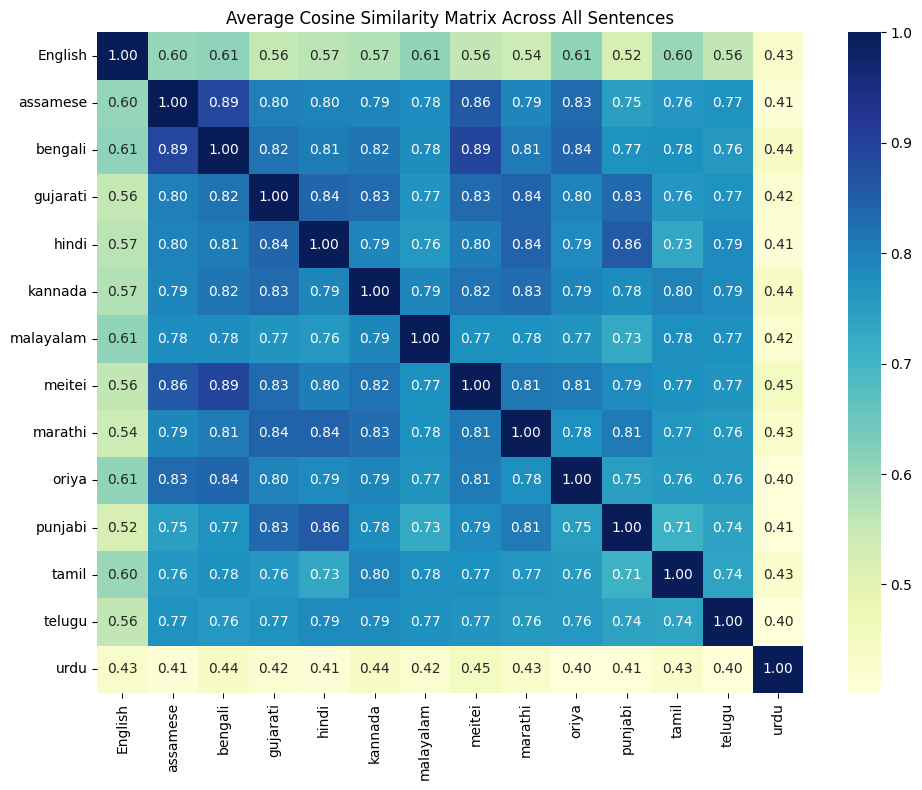

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(avg_similarity_matrix, annot=True, fmt=".2f",
            xticklabels=pm_ind_embeddings_df.columns.tolist(),
            yticklabels=pm_ind_embeddings_df.columns.tolist(),
            cmap="YlGnBu")
plt.title("Average Cosine Similarity Matrix Across All Sentences")
plt.tight_layout()
plt.show()


# Cosine Similarity on t-SNE reduced embeddings - IndicBERT

In [ ]:
tsne_wide_df = (
    tsne_df
    .assign(coords=lambda df: df[['x', 'y']].values.tolist())
    .pivot(index='Row', columns='Language', values='coords')
)

In [ ]:
tsne_wide_df.head()

Language,English,assamese,bengali,gujarati,hindi,kannada,malayalam,marathi,meitei,oriya,punjabi,tamil,telugu,urdu
Row,,,,,,,,,,,,,,
0,"[73.51153564453125, 78.79280090332031]","[-78.50884246826172, 12.94295597076416]","[-13.510808944702148, -27.796207427978516]","[-89.6005859375, -29.066781997680664]","[21.279827117919922, -96.48369598388672]","[40.98675537109375, -13.053170204162598]","[1.0057622194290161, 88.412841796875]","[9.079590797424316, 93.34902954101562]","[5.474884986877441, -42.34877014160156]","[-6.435197830200195, 53.84605407714844]","[-53.800167083740234, -85.46751403808594]","[33.063865661621094, 42.64223098754883]","[-70.30504608154297, 76.305419921875]","[114.00668334960938, -10.784546852111816]"
1,"[76.35356903076172, 91.64764404296875]","[-84.69014739990234, 12.580880165100098]","[1.4681214094161987, -17.725997924804688]","[-108.60607147216797, -30.13392448425293]","[15.614899635314941, -102.77478790283203]","[60.56515884399414, -9.614813804626465]","[-11.911860466003418, 99.49596405029297]","[3.658289909362793, -84.79740905761719]","[2.246824264526367, -18.105262756347656]","[-17.820762634277344, 41.909034729003906]","[-27.9870548248291, -108.56266021728516]","[38.1699104309082, 25.449268341064453]","[-81.2437973022461, 63.68970489501953]","[119.01819610595703, 14.071986198425293]"
2,"[70.67333984375, 83.62760162353516]","[-86.26890563964844, 3.2470946311950684]","[-2.203993797302246, -9.422574043273926]","[-88.61366271972656, -51.90447998046875]","[7.11621618270874, -101.17237854003906]","[53.283111572265625, -25.57735824584961]","[-19.496967315673828, 96.7488021850586]","[48.89638900756836, -71.87598419189453]","[-28.821781158447266, -46.35560989379883]","[1.4389350414276123, 57.03647232055664]","[-39.8112907409668, -88.20469665527344]","[54.06575012207031, 37.313716888427734]","[-77.0643310546875, 51.98525619506836]","[119.59278106689453, 14.793190956115723]"
3,"[57.56596374511719, 77.91605377197266]","[-77.23860931396484, 3.9628517627716064]","[-22.441099166870117, -14.79730224609375]","[-93.64675903320312, -43.11981964111328]","[1.4823753833770752, -93.80714416503906]","[62.76605224609375, -4.690256595611572]","[4.606250286102295, 94.24472045898438]","[49.15886306762695, -55.61189651489258]","[-15.439126014709473, -39.298770904541016]","[-25.560680389404297, 59.24043655395508]","[-51.977088928222656, -90.25010681152344]","[37.0565185546875, 37.5791130065918]","[-90.97209167480469, 53.02783203125]","[96.83528900146484, 8.7253999710083]"
4,"[80.66261291503906, 69.35820770263672]","[-91.90647888183594, 5.8787689208984375]","[1.7423481941223145, -0.12097432464361191]","[-105.69486999511719, -47.077022552490234]","[-7.320967674255371, -85.54048156738281]","[55.90480041503906, -27.131088256835938]","[-19.203258514404297, 92.7160415649414]","[29.14710235595703, -56.84100341796875]","[-30.004152297973633, -3.5027248859405518]","[-11.98779010772705, 26.220388412475586]","[-40.295509338378906, -110.97972869873047]","[53.41023635864258, 35.15595626831055]","[-77.10005950927734, 77.21284484863281]","[114.76673126220703, 16.132892608642578]"


In [ ]:
similarity_matrices_tsne = []  # to hold similarity matrix per sentence

for idx, row in tsne_wide_df.iterrows():
    embeddings = np.array(row.tolist())
    sim_matrix = cosine_similarity(embeddings)
    similarity_matrices_tsne.append(sim_matrix)

In [ ]:
# Stack all matrices: shape becomes [num_rows, num_langs, num_langs]
similarity_stack_tsne = np.stack(similarity_matrices_tsne)

# Mean similarity matrix across all rows
avg_similarity_matrix_tsne = np.mean(similarity_stack_tsne, axis=0)


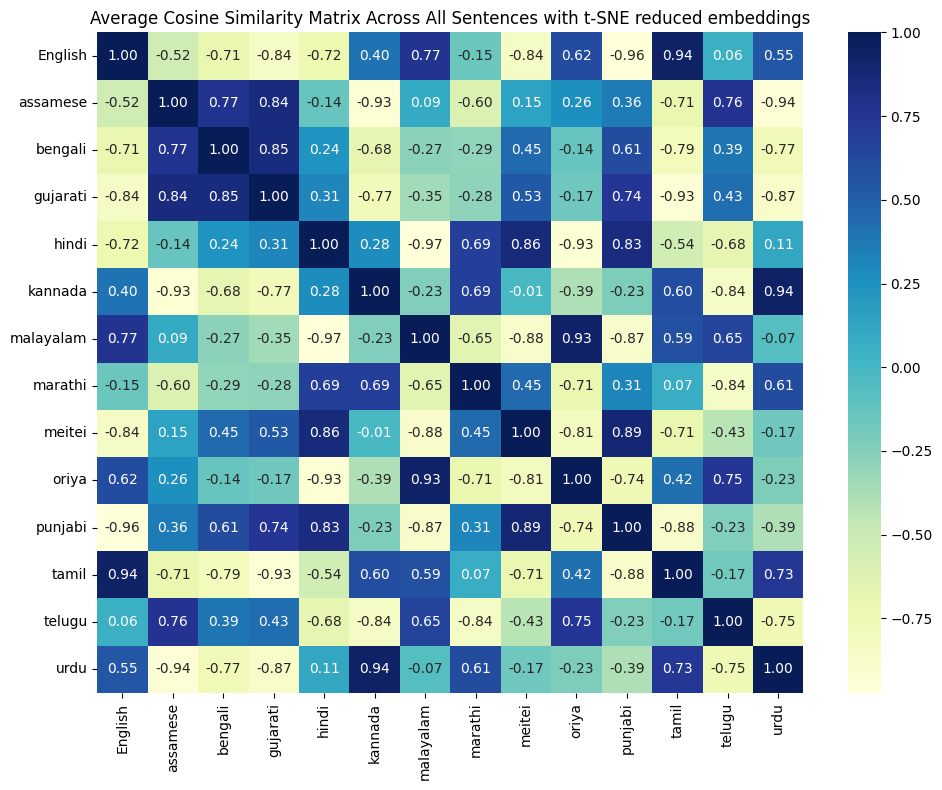

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(avg_similarity_matrix_tsne, annot=True, fmt=".2f",
            xticklabels=tsne_wide_df.columns.tolist(),
            yticklabels=tsne_wide_df.columns.tolist(),
            cmap="YlGnBu")
plt.title("Average Cosine Similarity Matrix Across All Sentences with t-SNE reduced embeddings")
plt.tight_layout()
plt.show()